# 04 - Integración de datos

Merge de las tres capas (clínica + DNA + proteína) por `patient_id` y comparación entre
controles y casos con toda la información junta.

**Pregunta que responde este notebook:** cuando se juntan las señales clínica, genética y
proteica de cada paciente, ¿qué capa aporta más a la diferencia entre sanos y Alzheimer, y
son coherentes entre sí?

**Entradas** (las generan los notebooks 01, 02 y 03)
- `results/tables/clinica_para_integracion.csv`
- `results/tables/dna_para_integracion.csv`
- `results/tables/proteina_para_integracion.csv`

**Salidas principales**
- `results/tables/dataset_integrado.csv` — una fila por paciente con las tres capas
- `results/tables/dataset_integrado_reducido.csv` — sin las ~500 columnas de cambios proteicos individuales
- `results/tables/comparacion_integrada_por_variable.csv` — tamaño de efecto de cada variable, con su capa
- `results/tables/coeficientes_modelo_integrado.csv` — peso de cada predictor (regresión logística)
- `results/tables/catboost_importancia.csv` — importancia de predictores (CatBoost)

> Datos **sintéticos** de uso docente. Todo lo observado es asociación descriptiva, no evidencia clínica.

**Uso de IA:** se usó apoyo de IA (Claude) para corregir la ruta de acceso a los datos y verificar que el notebook ejecute de punta a punta sin errores.

## 0. Configuración

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {"Sano": "#4C72B0", "Alzheimer": "#DD8452"}

GENES = ["APP", "PSEN1", "PSEN2", "APOE", "TREM2"]
RANDOM_STATE = 42

### Rutas

Misma lógica que los notebooks 02 y 03: `notebooks/` está un nivel bajo la raíz del proyecto,
así que las tablas se buscan en `../results/tables/`. No hay que escribir rutas propias.

In [2]:
from pathlib import Path

# notebooks/ -> raiz del proyecto
DIR_PROYECTO = Path.cwd().parent

DIR_RESULTADOS = DIR_PROYECTO / "results"
DIR_FIGURAS    = DIR_RESULTADOS / "figures"
DIR_TABLAS     = DIR_RESULTADOS / "tables"
(DIR_FIGURAS / "integracion").mkdir(parents=True, exist_ok=True)
DIR_TABLAS.mkdir(parents=True, exist_ok=True)

ARCHIVOS = {
    "clinica":  DIR_TABLAS / "clinica_para_integracion.csv",
    "dna":      DIR_TABLAS / "dna_para_integracion.csv",
    "proteina": DIR_TABLAS / "proteina_para_integracion.csv",
}

for etiqueta, ruta in ARCHIVOS.items():
    existe = ruta.exists()
    print(f"{etiqueta:<10} {'OK   ' if existe else 'FALTA'} {ruta}")
    if not existe:
        raise FileNotFoundError(
            f"Falta {ruta.name}. Ejecuta primero los notebooks 01, 02 y 03.")


def guardar_figura(nombre, subcarpeta="integracion"):
    ruta = DIR_FIGURAS / subcarpeta / f"{nombre}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    return ruta


def guardar_tabla(df, nombre, index=False):
    ruta = DIR_TABLAS / f"{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


print("\nResultados en:", DIR_RESULTADOS)

clinica    OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results/tables/clinica_para_integracion.csv
dna        OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results/tables/dna_para_integracion.csv
proteina   OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results/tables/proteina_para_integracion.csv

Resultados en: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results


---
## 1. Lectura de las tres capas

Cada notebook anterior dejó su capa ya resumida por paciente. Aquí solo se leen y se revisan
sus dimensiones. Las tres deberían tener 1.000 filas (una por paciente).

In [3]:
clinica  = pd.read_csv(ARCHIVOS["clinica"])
dna      = pd.read_csv(ARCHIVOS["dna"])
proteina = pd.read_csv(ARCHIVOS["proteina"])

print("clinica :", clinica.shape)
print("dna     :", dna.shape)
print("proteina:", proteina.shape)

print("\nColumnas de la capa clinica:")
print(list(clinica.columns))

clinica.head()

clinica : (1000, 8)
dna     : (1000, 22)
proteina: (1000, 518)

Columnas de la capa clinica:
['patient_id', 'alzheimer', 'age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'hypertension', 'family_history_alzheimer', 'sex_female']


,patient_id,alzheimer,age,systolic_bp_mmHg,diastolic_bp_mmHg,hypertension,family_history_alzheimer,sex_female
0,P0001,1,75,137,77,0,0,1
1,P0002,1,50,99,78,0,0,1
2,P0003,1,82,153,85,1,1,0
3,P0004,1,72,121,75,0,1,1
4,P0005,0,64,153,74,0,1,1


---
## 2. Control de calidad del cruce

Antes de unir nada hay que verificar dos cosas, porque si fallan el *merge* produce un dataset
silenciosamente incorrecto:

1. **Los `patient_id` coinciden entre las tres capas.** Si un paciente está en una capa y no en
   otra, el *merge* lo descartaría (inner) o dejaría huecos (outer).
2. **La etiqueta `alzheimer` es la misma para cada paciente en las tres capas.** Las tres traen
   su propia copia; si no coinciden, alguna capa se generó con datos distintos.

In [4]:
COL_ID = "patient_id"

ids_clinica  = set(clinica[COL_ID])
ids_dna      = set(dna[COL_ID])
ids_proteina = set(proteina[COL_ID])

print("Pacientes por capa:")
print("   clinica :", len(ids_clinica))
print("   dna     :", len(ids_dna))
print("   proteina:", len(ids_proteina))

comunes = ids_clinica & ids_dna & ids_proteina
print("\nPresentes en las tres capas:", len(comunes))
print("Solo en clinica :", sorted(ids_clinica - ids_dna - ids_proteina)[:5] or "ninguno")
print("Solo en dna     :", sorted(ids_dna - ids_clinica - ids_proteina)[:5] or "ninguno")
print("Solo en proteina:", sorted(ids_proteina - ids_clinica - ids_dna)[:5] or "ninguno")

print("\nIDs duplicados dentro de cada capa:")
for etiqueta, df_ in [("clinica", clinica), ("dna", dna), ("proteina", proteina)]:
    print(f"   {etiqueta:<9} {df_[COL_ID].duplicated().sum()}")

Pacientes por capa:
   clinica : 1000
   dna     : 1000
   proteina: 1000

Presentes en las tres capas: 1000
Solo en clinica : ninguno
Solo en dna     : ninguno
Solo en proteina: ninguno

IDs duplicados dentro de cada capa:
   clinica   0
   dna       0
   proteina  0


In [5]:
# La etiqueta alzheimer debe coincidir paciente a paciente entre las tres capas
etiquetas = (
    clinica[[COL_ID, "alzheimer"]].rename(columns={"alzheimer": "alz_clinica"})
    .merge(dna[[COL_ID, "alzheimer"]].rename(columns={"alzheimer": "alz_dna"}), on=COL_ID)
    .merge(proteina[[COL_ID, "alzheimer"]].rename(columns={"alzheimer": "alz_proteina"}), on=COL_ID)
)

coincide = ((etiquetas["alz_clinica"] == etiquetas["alz_dna"]) &
            (etiquetas["alz_clinica"] == etiquetas["alz_proteina"]))

print(f"Etiqueta consistente en las tres capas: {coincide.sum()} de {len(etiquetas)}")
if not coincide.all():
    display(etiquetas[~coincide])
    raise ValueError("Hay pacientes con etiqueta distinta entre capas. Revisar antes de integrar.")
print("La etiqueta 'alzheimer' coincide en todos los pacientes.")

Etiqueta consistente en las tres capas: 1000 de 1000
La etiqueta 'alzheimer' coincide en todos los pacientes.


---
## 3. Merge por `patient_id`

Se une clínica + DNA + proteína en una sola tabla, una fila por paciente. Como las tres capas
traen su propia columna `alzheimer` y ya verificamos que coinciden, se conserva solo la de la
capa clínica y se quita de las otras dos para no duplicarla.

In [6]:
# Quitamos la etiqueta repetida de las capas dna y proteina (ya verificada arriba)
dna_sin_label      = dna.drop(columns=["alzheimer"])
proteina_sin_label = proteina.drop(columns=["alzheimer"])

integrado = (clinica
             .merge(dna_sin_label,      on=COL_ID, how="inner")
             .merge(proteina_sin_label, on=COL_ID, how="inner"))

integrado["diagnostico"] = integrado["alzheimer"].map({0: "Sano", 1: "Alzheimer"})

print("Dataset integrado:", integrado.shape)
print("Pacientes:", integrado[COL_ID].nunique(), "| Columnas:", integrado.shape[1])
print("\nReparto de grupos:")
print(integrado["diagnostico"].value_counts().to_string())

guardar_tabla(integrado, "dataset_integrado")
integrado.head()

Dataset integrado: (1000, 545)
Pacientes: 1000 | Columnas: 545

Reparto de grupos:
diagnostico
Sano         657
Alzheimer    343


/tmp/ipykernel_9304/4089849948.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  integrado["diagnostico"] = integrado["alzheimer"].map({0: "Sano", 1: "Alzheimer"})


,patient_id,alzheimer,age,systolic_bp_mmHg,diastolic_bp_mmHg,hypertension,family_history_alzheimer,sex_female,n_cambios_APP,n_cambios_PSEN1,n_cambios_PSEN2,n_cambios_APOE,n_cambios_TREM2,carga_total,n_SNP,n_delecion,n_insercion,categoria_carga,APOE:205:T>G,APOE:311:C>T,PSEN1:133:C>A,TREM2:251:C>A,APP:217:G>C,TREM2:529:C>A,PSEN1:374:C>G,PSEN2:615:T>G,APP:452:C>G,PSEN2:166:T>C,n_cambios_prot_APP,n_cambios_prot_PSEN1,n_cambios_prot_PSEN2,n_cambios_prot_APOE,n_cambios_prot_TREM2,n_cambios_prot_total,frameshift_APP,frameshift_PSEN1,frameshift_PSEN2,frameshift_APOE,frameshift_TREM2,n_proteinas_con_frameshift,...,APOE:p.D186T,APOE:p.T198D,PSEN2:p.K226F,PSEN2:p.DAKHKY197-,APOE:p.A189-,PSEN2:p.A203N,APOE:p.Q193A,APOE:p.T197-,APOE:p.E190S,APOE:p.G199R,APOE:p.P194V,APP:p.L188Q,PSEN2:p.L220H,PSEN2:p.NGT210-,PSEN2:p.L235P,PSEN2:p.RSNIS215-,PSEN2:p.R240D,PSEN2:p.R223V,PSEN2:p.R222V,PSEN2:p.K244A,PSEN2:p.K206Q,PSEN2:p.E237-,PSEN2:p.T213E,PSEN2:p.-251RSPVPDG,PSEN2:p.-225F,PSEN2:p.A241H,PSEN2:p.X221C,PSEN2:p.A208X,PSEN2:p.T243H,PSEN2:p.SFTRF229-,PSEN2:p.Y234G,APOE:p.A182V,APOE:p.D179H,PSEN2:p.A100-,PSEN2:p.S136I,PSEN2:p.A247I,PSEN2:p.-249G,PSEN2:p.-246I,PSEN2:p.-247WK,diagnostico
0,P0001,1,75,137,77,0,0,1,0,3,1,1,1,6,5,1,0,3 o más,0,0,0,0,0,0,0,0,0,0,0,1,63,1,1,66,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Alzheimer
1,P0002,1,50,99,78,0,0,1,2,1,2,4,0,9,7,1,1,3 o más,1,1,0,0,1,0,0,0,0,0,86,0,63,3,0,152,1,0,1,0,0,2,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Alzheimer
2,P0003,1,82,153,85,1,1,0,0,4,3,0,2,9,8,0,1,3 o más,0,0,0,0,0,1,0,0,0,1,0,4,3,0,2,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Alzheimer
3,P0004,1,72,121,75,0,1,1,0,2,0,3,2,7,6,0,1,3 o más,1,1,0,0,0,1,0,0,0,0,0,2,0,3,26,31,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Alzheimer
4,P0005,0,64,153,74,0,1,1,1,0,2,2,2,7,6,1,0,3 o más,1,1,0,1,0,0,0,0,0,0,1,0,2,2,7,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Sano


**Qué decir en la defensa.** El *merge* se hace por `patient_id` porque es la única llave que
comparten las tres capas: cada tipo de dato (ficha clínica, FASTA de genes, FASTA de proteínas)
se generó por separado y solo el identificador del paciente los conecta. Se usó *inner join*
porque el control de calidad ya confirmó que los 1.000 pacientes están en las tres capas; con
huecos habría que decidir entre descartar (inner) o imputar (outer).

---
## 4. Comparación entre grupos, capa por capa

La pregunta central: con todo junto, ¿qué variables separan mejor a sanos de Alzheimer, y de
qué capa vienen? Se usa el mismo **d de Cohen** de los notebooks anteriores para poder comparar
variables de distinta naturaleza en una escala común.

$$d = \frac{\bar{x}_{Alzheimer} - \bar{x}_{sano}}{s_{combinada}}$$

Referencia: |d| ≈ 0.2 pequeño, 0.5 mediano, 0.8 grande.

In [7]:
def d_de_cohen(x, y):
    """Diferencia de medias en unidades de desviacion estandar combinada."""
    nx, ny = len(x), len(y)
    s = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / s if s > 0 else 0.0


# Procedencia de cada columna: se define a partir de las capas ORIGINALES,
# antes del merge, para saber con certeza de que tipo de dato viene cada variable.
cols_clinica = [c for c in clinica.columns  if c not in (COL_ID, "alzheimer")]
cols_dna     = [c for c in dna.columns      if c not in (COL_ID, "alzheimer", "categoria_carga")]
cols_prot    = [c for c in proteina.columns if c not in (COL_ID, "alzheimer")]

capa_de = {}
for c in cols_clinica: capa_de[c] = "clinica"
for c in cols_dna:     capa_de[c] = "dna"
for c in cols_prot:    capa_de[c] = "proteina"

print("Variables por capa: clinica =", len(cols_clinica),
      "| dna =", len(cols_dna), "| proteina =", len(cols_prot))

Variables por capa: clinica = 6 | dna = 19 | proteina = 516


In [8]:
enf = integrado[integrado["alzheimer"] == 1]
san = integrado[integrado["alzheimer"] == 0]

filas = []
for c, capa in capa_de.items():
    serie = integrado[c]
    if not np.issubdtype(serie.dtype, np.number):
        continue   # se saltan columnas de texto (p. ej. categoria_carga)
    es_binaria = set(serie.dropna().unique()) <= {0, 1}
    fila = {
        "variable": c,
        "capa": capa,
        "naturaleza": "binaria" if es_binaria else "numerica",
        "media_sano": san[c].mean(),
        "media_alzheimer": enf[c].mean(),
        "diferencia": enf[c].mean() - san[c].mean(),
        "efecto_d": d_de_cohen(enf[c], san[c]),
        "diferencia_pct_puntos": (enf[c].mean() - san[c].mean()) * 100 if es_binaria else np.nan,
    }
    filas.append(fila)

comparacion = pd.DataFrame(filas).round(4)
comparacion = comparacion.reindex(
    comparacion["efecto_d"].abs().sort_values(ascending=False).index).reset_index(drop=True)

guardar_tabla(comparacion, "comparacion_integrada_por_variable")
print("Variables comparadas:", len(comparacion))
print("\nTop 20 por tamaño de efecto:")
comparacion.head(20)

Variables comparadas: 541

Top 20 por tamaño de efecto:


,variable,capa,naturaleza,media_sano,media_alzheimer,diferencia,efecto_d,diferencia_pct_puntos
0,carga_total,dna,numerica,4.0213,6.3586,2.3373,1.1098,NaN
1,n_SNP,dna,numerica,3.6986,5.7493,2.0506,1.0171,NaN
2,APOE:205:T>G,dna,binaria,0.1933,0.6006,0.4073,0.9466,40.7280
3,APOE:311:C>T,dna,binaria,0.1933,0.6006,0.4073,0.9466,40.7280
4,APOE:p.C69G,proteina,binaria,0.1903,0.5948,0.4045,0.9423,40.4493
5,APOE:p.T104I,proteina,binaria,0.1887,0.5918,0.4031,0.9402,40.3100
6,age,clinica,numerica,65.6545,74.7930,9.1385,0.9087,NaN
7,PSEN1:133:C>A,dna,binaria,0.0289,0.2624,0.2335,0.8008,23.3471
8,PSEN1:p.H45N,proteina,binaria,0.0289,0.2595,0.2306,0.7930,23.0556
9,n_cambios_APOE,dna,numerica,1.0685,1.8280,0.7595,0.6567,NaN


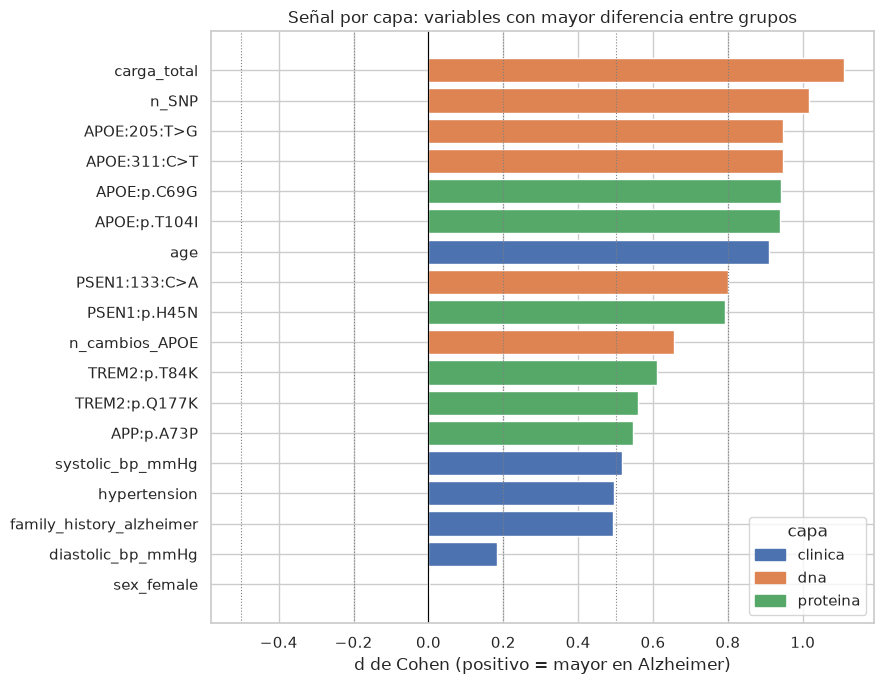

In [9]:
# Mejor senal de cada capa: hasta 6 variables con mayor |d| por capa
top_por_capa = (comparacion.reindex(comparacion["efecto_d"].abs()
                                    .sort_values(ascending=False).index)
                .groupby("capa", as_index=False).head(6))

colores_capa = {"clinica": "#4C72B0", "dna": "#DD8452", "proteina": "#55A868"}
datos = top_por_capa.sort_values("efecto_d")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(datos["variable"], datos["efecto_d"],
        color=[colores_capa[c] for c in datos["capa"]])
ax.axvline(0, color="black", lw=0.8)
for umbral in [-0.5, -0.2, 0.2, 0.5, 0.8]:
    ax.axvline(umbral, color="grey", ls=":", lw=0.8)
ax.set(xlabel="d de Cohen (positivo = mayor en Alzheimer)", ylabel="",
       title="Señal por capa: variables con mayor diferencia entre grupos")

manijas = [plt.Rectangle((0, 0), 1, 1, color=colores_capa[c]) for c in colores_capa]
ax.legend(manijas, list(colores_capa), title="capa")
plt.tight_layout()
guardar_figura("senal_por_capa")
plt.show()

**Cómo leer esta figura.** Cada barra es una variable; el color indica de qué capa viene.
Permite ver de un vistazo si la separación entre grupos la aportan sobre todo las variables
clínicas (edad, presión), las genéticas (haplotipo APOE, carga mutacional) o las proteicas.
En los notebooks anteriores la edad clínica (d ≈ 0.91) y el haplotipo APOE (≈ 60% vs 19% de
portadores) fueron las señales más fuertes de sus respectivas capas; esta vista las pone lado
a lado en la misma escala.

---
## 5. Coherencia entre capas

Integrar no es solo apilar columnas: hay que comprobar que las capas **cuentan la misma
historia** donde deberían. Dos comprobaciones directas:

1. La **carga mutacional de DNA** debería relacionarse con la **carga de cambios proteicos**.
2. El **haplotipo APOE** detectado en DNA (nb 02) y el cambio *missense* de APOE en proteína
   (nb 03) deberían marcar a los mismos pacientes.

Correlacion (Pearson) carga DNA vs carga proteica: r = 0.256


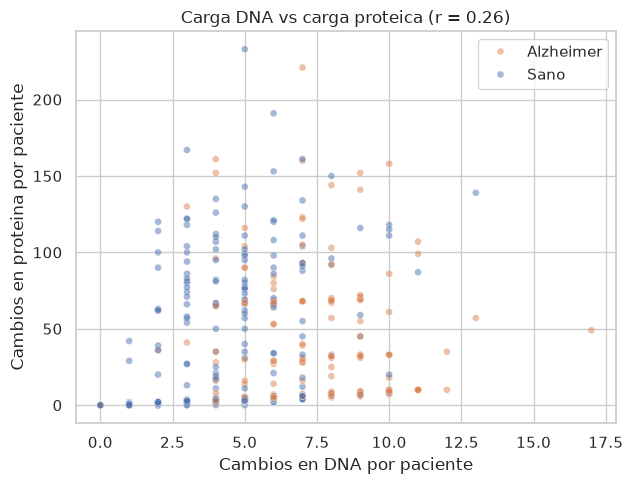

In [10]:
# 1) Carga DNA vs carga proteica
r_carga = integrado["carga_total"].corr(integrado["n_cambios_prot_total"])
print(f"Correlacion (Pearson) carga DNA vs carga proteica: r = {r_carga:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(data=integrado, x="carga_total", y="n_cambios_prot_total",
                hue="diagnostico", palette=PALETA, alpha=0.5, s=25, ax=ax)
ax.set(xlabel="Cambios en DNA por paciente", ylabel="Cambios en proteina por paciente",
       title=f"Carga DNA vs carga proteica (r = {r_carga:.2f})")
ax.legend(title="")
plt.tight_layout()
guardar_figura("dna_vs_proteina_carga")
plt.show()

La relación es positiva pero **no perfecta**, y ese desajuste es informativo: un solo
nucleótido insertado o borrado (indel *frameshift*) corre el marco de lectura y altera cientos
de aminoácidos. Por eso hay pacientes con poca carga de DNA y muchísima carga proteica: son los
portadores de *frameshift*. Es la misma amplificación que explicaba en el nb 03 por qué se
detectan muchas más sustituciones en proteína que SNPs en DNA.

In [11]:
# 2) Concordancia del haplotipo APOE entre DNA y proteina
col_dna_apoe  = next((c for c in integrado.columns if c.startswith("APOE:") and ">" in c), None)
col_prot_apoe = next((c for c in integrado.columns if c.startswith("APOE:p.")), None)

print("Columna DNA  APOE:", col_dna_apoe)
print("Columna prot APOE:", col_prot_apoe)

if col_dna_apoe and col_prot_apoe:
    tabla = pd.crosstab(integrado[col_dna_apoe], integrado[col_prot_apoe],
                        rownames=[f"DNA {col_dna_apoe}"],
                        colnames=[f"prot {col_prot_apoe}"])
    print("\nPortador (1) / no portador (0) en cada capa:")
    display(tabla)
    acuerdo = (integrado[col_dna_apoe] == integrado[col_prot_apoe]).mean() * 100
    print(f"Coinciden en {acuerdo:.1f}% de los pacientes.")
else:
    print("No se encontraron ambas columnas de APOE en el dataset integrado.")

Columna DNA  APOE: APOE:205:T>G
Columna prot APOE: APOE:p.C69G

Portador (1) / no portador (0) en cada capa:


prot APOE:p.C69G,0,1
DNA APOE:205:T>G,,
0,667,0
1,4,329


Coinciden en 99.6% de los pacientes.


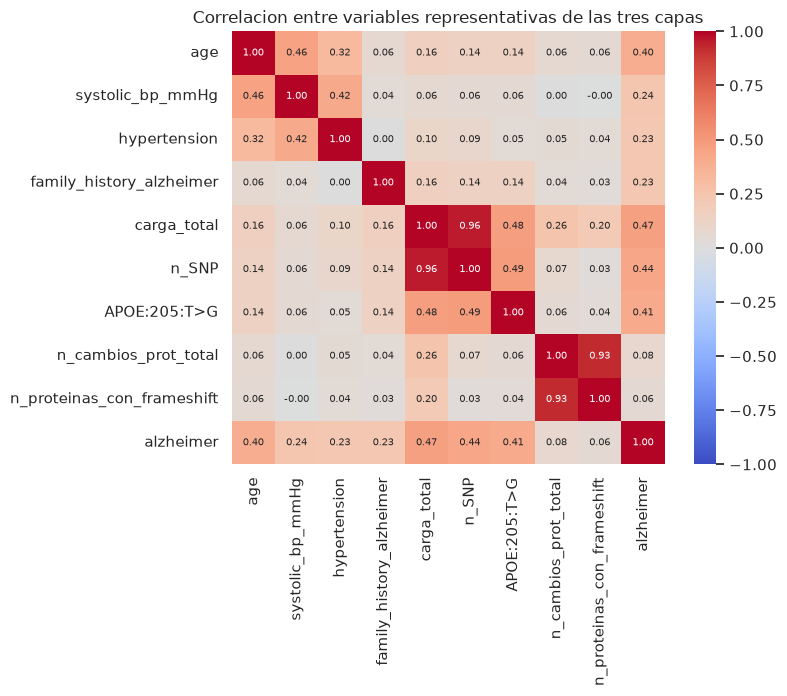

In [12]:
# Correlacion entre variables representativas de las tres capas
representativas = ["age", "systolic_bp_mmHg", "hypertension", "family_history_alzheimer",
                   "carga_total", "n_SNP"]
if col_dna_apoe:
    representativas.append(col_dna_apoe)
representativas += ["n_cambios_prot_total", "n_proteinas_con_frameshift"]

cols_rep = [c for c in representativas if c in integrado.columns]
corr = integrado[cols_rep + ["alzheimer"]].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"size": 7}, ax=ax)
ax.set(title="Correlacion entre variables representativas de las tres capas")
plt.tight_layout()
guardar_figura("correlacion_entre_capas")
plt.show()

**Qué mirar en el mapa de calor.** La última fila/columna (`alzheimer`) muestra qué tan
asociada está cada variable con el diagnóstico. Y los bloques fuera de la diagonal muestran la
estructura: las variables clínicas se correlacionan entre sí (edad–presión), las genéticas
entre sí, y las capas son **relativamente independientes** entre bloques. Eso es justamente lo
que hace útil integrarlas: cada capa aporta información que las otras no tienen.

---
## 6. Vista integrada con PCA

Un PCA sobre las variables **numéricas** de las tres capas, estandarizadas, para ver si con
todo junto los grupos se separan mejor que con una sola capa. Las binarias quedan fuera:
estandarizar un 0/1 no da una distancia interpretable (mismo criterio que el nb 01).

Es un método **no supervisado**: busca los ejes de máxima varianza, no los que separan sanos de
enfermos. Si los grupos no se separan limpiamente, es un resultado válido.

Variables en el PCA integrado: ['age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'carga_total', 'n_SNP', 'n_cambios_prot_total', 'n_proteinas_con_frameshift']
Varianza explicada por componente (%): [32.8 24.6 21.2 12.4  7.6  1.   0.3]
Acumulada PC1+PC2: 57.4%
Efecto entre grupos sobre PC1: d = +1.007


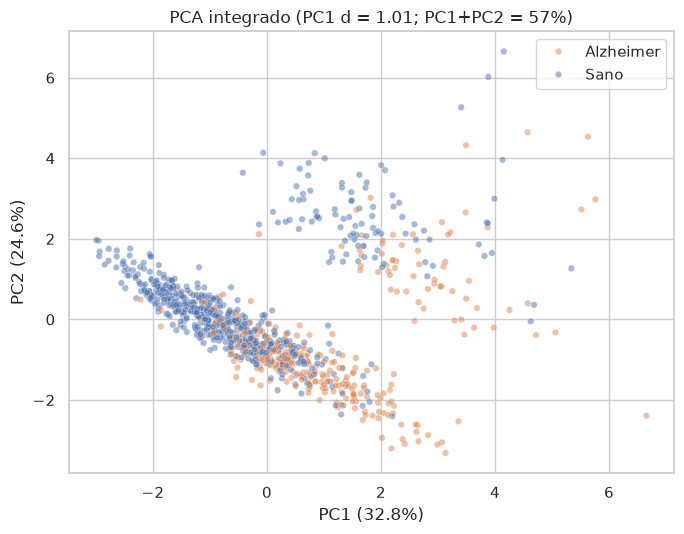

,PC1,PC2
age,0.221,-0.279
systolic_bp_mmHg,0.140,-0.288
diastolic_bp_mmHg,0.080,-0.178
carga_total,0.548,-0.296
n_SNP,0.475,-0.404
n_cambios_prot_total,0.458,0.516
n_proteinas_con_frameshift,0.435,0.538


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

VARS_PCA = ["age", "systolic_bp_mmHg", "diastolic_bp_mmHg",
            "carga_total", "n_SNP", "n_cambios_prot_total",
            "n_proteinas_con_frameshift"]
VARS_PCA = [v for v in VARS_PCA if v in integrado.columns]
print("Variables en el PCA integrado:", VARS_PCA)

X = StandardScaler().fit_transform(integrado[VARS_PCA])
pca = PCA(random_state=RANDOM_STATE)
scores = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_

print("Varianza explicada por componente (%):", np.round(var_exp * 100, 1))
print(f"Acumulada PC1+PC2: {var_exp[:2].sum() * 100:.1f}%")

df_pca = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"])
df_pca["diagnostico"] = integrado["diagnostico"].values

d_pc1 = d_de_cohen(df_pca[df_pca["diagnostico"] == "Alzheimer"]["PC1"],
                   df_pca[df_pca["diagnostico"] == "Sano"]["PC1"])
print(f"Efecto entre grupos sobre PC1: d = {d_pc1:+.3f}")

cargas = pd.DataFrame(pca.components_[:2].T, index=VARS_PCA, columns=["PC1", "PC2"]).round(3)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="diagnostico", palette=PALETA,
                alpha=0.5, s=22, ax=ax)
ax.set(title=f"PCA integrado (PC1 d = {d_pc1:.2f}; PC1+PC2 = {var_exp[:2].sum() * 100:.0f}%)",
       xlabel=f"PC1 ({var_exp[0] * 100:.1f}%)", ylabel=f"PC2 ({var_exp[1] * 100:.1f}%)")
ax.legend(title="")

plt.tight_layout()
guardar_figura("pca_integrado")
plt.show()

display(cargas)

**Cómo interpretarlo.** Mirar el número (d sobre PC1) y la nube a la vez. Aunque las medias se
desplacen, los grupos se **superponen**: con esta proyección no se clasifica a un paciente
individual, solo se describe la cohorte. Las cargas dicen qué variables pesan en cada eje; si
PC1 mezcla edad clínica con carga genética, significa que la separación integrada combina
señales de más de una capa.

---
## 7. (Opcional) Modelo integrado simple

La guía es descriptiva, así que esta sección es **una demostración, no un objetivo**: un modelo
sencillo para ilustrar que juntar capas puede separar mejor los grupos que una sola. Se usa una
**regresión logística** con pocos predictores explícitos y una partición *train/test*. Como los
datos son sintéticos, el resultado no tiene valor clínico.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Un predictor representativo por capa (se agregan solo si existen en el dataset)
FEATURES = [c for c in ["age", "systolic_bp_mmHg", "hypertension",
                        "family_history_alzheimer", "sex_female",
                        "carga_total"] if c in integrado.columns]
if col_dna_apoe:
    FEATURES.append(col_dna_apoe)
FEATURES += [c for c in ["n_proteinas_con_frameshift"] if c in integrado.columns]

print("Predictores:", FEATURES)

X = integrado[FEATURES].astype(float)
y = integrado["alzheimer"].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

escalador = StandardScaler().fit(X_tr)
modelo = LogisticRegression(max_iter=1000)
modelo.fit(escalador.transform(X_tr), y_tr)

prob_te = modelo.predict_proba(escalador.transform(X_te))[:, 1]
pred_te = (prob_te >= 0.5).astype(int)

print(f"\nExactitud (test): {accuracy_score(y_te, pred_te):.3f}")
print(f"AUC (test):       {roc_auc_score(y_te, prob_te):.3f}")

coef = (pd.DataFrame({"variable": FEATURES, "coeficiente": modelo.coef_[0]})
        .sort_values("coeficiente", key=abs, ascending=False).round(3))
guardar_tabla(coef, "coeficientes_modelo_integrado")
print("\nPeso de cada predictor (variables estandarizadas):")
display(coef)

Predictores: ['age', 'systolic_bp_mmHg', 'hypertension', 'family_history_alzheimer', 'sex_female', 'carga_total', 'APOE:205:T>G', 'n_proteinas_con_frameshift']

Exactitud (test): 0.820
AUC (test):       0.869

Peso de cada predictor (variables estandarizadas):


,variable,coeficiente
5,carga_total,0.968
0,age,0.958
6,APOE:205:T>G,0.545
3,family_history_alzheimer,0.337
2,hypertension,0.258
7,n_proteinas_con_frameshift,-0.122
1,systolic_bp_mmHg,0.107
4,sex_female,0.080


**Cómo leer los coeficientes.** Están sobre variables estandarizadas, así que se comparan
entre sí: un coeficiente positivo empuja hacia *Alzheimer* y uno negativo hacia *sano*, y la
magnitud indica el peso. Es esperable que edad y haplotipo APOE queden entre los más grandes,
porque fueron las señales más fuertes en sus capas. Límite importante: el AUC alto refleja que
las asociaciones fueron **sembradas** por el generador del dataset, no un hallazgo biológico.

---
## 8. CatBoost: modelo con variables categóricas

*CatBoost* es un algoritmo de *machine learning* basado en árboles de decisión, pensado para
manejar variables **categóricas** (la categoría de carga mutacional, el sexo, portar o no una
variante) sin preprocesamiento complejo. Se usa como modelo integrado y se compara con la regresión
logística de la sección 7.

Requiere el paquete `catboost` (`pip install catboost`). Si no está instalado, la celda lo avisa y
se salta sin romper el notebook.

In [15]:
%pip install catboost
try:
    from catboost import CatBoostClassifier
    hay_catboost = True
except ImportError:
    hay_catboost = False
    print("catboost no esta instalado. Para esta seccion ejecuta: pip install catboost")

if hay_catboost:
    # Predictores numericos y categoricos. CatBoost recibe las categoricas tal cual.
    NUMERICAS = [c for c in ["age", "systolic_bp_mmHg", "diastolic_bp_mmHg",
                             "carga_total", "n_SNP", "n_delecion", "n_insercion",
                             "n_cambios_prot_total", "n_proteinas_con_frameshift"]
                 if c in integrado.columns]
    CATEGORICAS = [c for c in ["categoria_carga", "sex_female", "hypertension",
                               "family_history_alzheimer"]
                   if c in integrado.columns]
    if col_dna_apoe:
        CATEGORICAS.append(col_dna_apoe)

    FEATURES_CB = NUMERICAS + CATEGORICAS
    print("Numericas  :", NUMERICAS)
    print("Categoricas:", CATEGORICAS)

    Xcb = integrado[FEATURES_CB].copy()
    for c in CATEGORICAS:              # CatBoost espera las categoricas como texto
        Xcb[c] = Xcb[c].astype(str)
    ycb = integrado["alzheimer"].astype(int)

    Xcb_tr, Xcb_te, ycb_tr, ycb_te = train_test_split(
        Xcb, ycb, test_size=0.3, random_state=RANDOM_STATE, stratify=ycb)

    modelo_cb = CatBoostClassifier(
        iterations=300, depth=4, learning_rate=0.05,
        random_seed=RANDOM_STATE, verbose=False)
    modelo_cb.fit(Xcb_tr, ycb_tr, cat_features=CATEGORICAS)

    prob_cb = modelo_cb.predict_proba(Xcb_te)[:, 1]
    pred_cb = (prob_cb >= 0.5).astype(int)

    print(f"\nExactitud (test): {accuracy_score(ycb_te, pred_cb):.3f}")
    print(f"AUC (test):       {roc_auc_score(ycb_te, prob_cb):.3f}")

    importancia = (pd.DataFrame({"variable": FEATURES_CB,
                                 "importancia": modelo_cb.get_feature_importance()})
                   .sort_values("importancia", ascending=False)
                   .round(2).reset_index(drop=True))
    guardar_tabla(importancia, "catboost_importancia")
    display(importancia)

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/97.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/97.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/97.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/97.1 MB ? eta -:--:--

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]


Note: you may need to restart the kernel to use updated packages.


Numericas  : ['age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'carga_total', 'n_SNP', 'n_delecion', 'n_insercion', 'n_cambios_prot_total', 'n_proteinas_con_frameshift']
Categoricas: ['categoria_carga', 'sex_female', 'hypertension', 'family_history_alzheimer', 'APOE:205:T>G']



Exactitud (test): 0.827
AUC (test):       0.878


,variable,importancia
0,age,21.80
1,systolic_bp_mmHg,12.86
2,carga_total,10.98
3,n_cambios_prot_total,10.51
4,n_SNP,9.20
5,APOE:205:T>G,7.66
6,diastolic_bp_mmHg,6.66
7,categoria_carga,5.16
8,family_history_alzheimer,4.87
9,hypertension,3.24


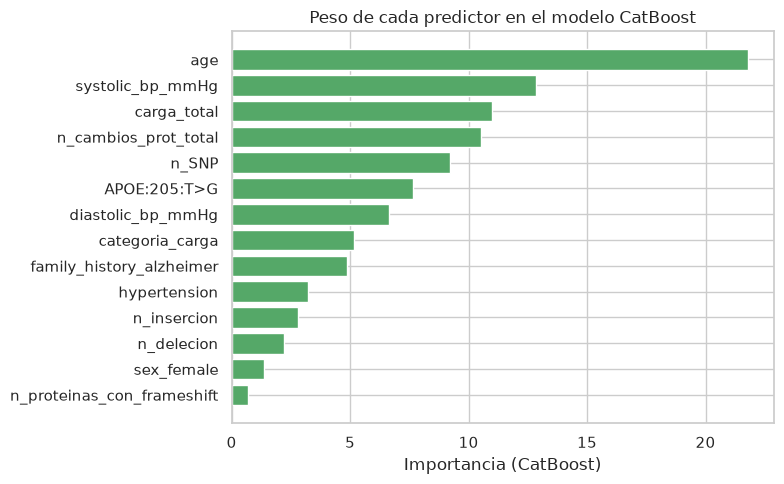

In [16]:
if hay_catboost:
    datos_imp = importancia.sort_values("importancia")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(datos_imp["variable"], datos_imp["importancia"], color="#55A868")
    ax.set(xlabel="Importancia (CatBoost)", ylabel="",
           title="Peso de cada predictor en el modelo CatBoost")
    plt.tight_layout()
    guardar_figura("catboost_importancia")
    plt.show()

**Cómo leerlo.** La importancia indica cuánto usó *CatBoost* cada variable para separar los
grupos (no la dirección, solo el peso). Es esperable que edad y haplotipo APOE queden arriba,
consistente con la sección 4. Comparar el AUC con el de la regresión logística (sección 7) muestra
si un modelo no lineal que aprovecha las categóricas gana algo. Con datos sintéticos, un AUC alto
refleja las asociaciones sembradas, no capacidad diagnóstica real.

---
## 9. Exportar el dataset integrado

Ya se guardó `dataset_integrado.csv` en el paso 3. Aquí se guarda además una versión
**reducida** sin las ~500 columnas de cambios proteicos individuales (`GEN:p.XnY`), que son
útiles para rastrear un cambio puntual pero incómodas para una tabla de trabajo.

In [17]:
cols_cambios_prot = [c for c in integrado.columns if ":p." in c]
reducido = integrado.drop(columns=cols_cambios_prot)

print("Columnas de cambios proteicos individuales retiradas:", len(cols_cambios_prot))
print("Dataset reducido:", reducido.shape)
print("\nColumnas conservadas:")
print(list(reducido.columns))

guardar_tabla(reducido, "dataset_integrado_reducido")
reducido.head()

Columnas de cambios proteicos individuales retiradas: 496
Dataset reducido: (1000, 49)

Columnas conservadas:
['patient_id', 'alzheimer', 'age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'hypertension', 'family_history_alzheimer', 'sex_female', 'n_cambios_APP', 'n_cambios_PSEN1', 'n_cambios_PSEN2', 'n_cambios_APOE', 'n_cambios_TREM2', 'carga_total', 'n_SNP', 'n_delecion', 'n_insercion', 'categoria_carga', 'APOE:205:T>G', 'APOE:311:C>T', 'PSEN1:133:C>A', 'TREM2:251:C>A', 'APP:217:G>C', 'TREM2:529:C>A', 'PSEN1:374:C>G', 'PSEN2:615:T>G', 'APP:452:C>G', 'PSEN2:166:T>C', 'n_cambios_prot_APP', 'n_cambios_prot_PSEN1', 'n_cambios_prot_PSEN2', 'n_cambios_prot_APOE', 'n_cambios_prot_TREM2', 'n_cambios_prot_total', 'frameshift_APP', 'frameshift_PSEN1', 'frameshift_PSEN2', 'frameshift_APOE', 'frameshift_TREM2', 'n_proteinas_con_frameshift', 'carga_neta_APOE', 'carga_neta_TREM2', 'frac_cargada_APOE', 'frac_cargada_TREM2', 'frac_hidrofobica_APOE', 'frac_hidrofobica_TREM2', 'largo_APOE', 'largo_TREM2'

,patient_id,alzheimer,age,systolic_bp_mmHg,diastolic_bp_mmHg,hypertension,family_history_alzheimer,sex_female,n_cambios_APP,n_cambios_PSEN1,n_cambios_PSEN2,n_cambios_APOE,n_cambios_TREM2,carga_total,n_SNP,n_delecion,n_insercion,categoria_carga,APOE:205:T>G,APOE:311:C>T,PSEN1:133:C>A,TREM2:251:C>A,APP:217:G>C,TREM2:529:C>A,PSEN1:374:C>G,PSEN2:615:T>G,APP:452:C>G,PSEN2:166:T>C,n_cambios_prot_APP,n_cambios_prot_PSEN1,n_cambios_prot_PSEN2,n_cambios_prot_APOE,n_cambios_prot_TREM2,n_cambios_prot_total,frameshift_APP,frameshift_PSEN1,frameshift_PSEN2,frameshift_APOE,frameshift_TREM2,n_proteinas_con_frameshift,carga_neta_APOE,carga_neta_TREM2,frac_cargada_APOE,frac_cargada_TREM2,frac_hidrofobica_APOE,frac_hidrofobica_TREM2,largo_APOE,largo_TREM2,diagnostico
0,P0001,1,75,137,77,0,0,1,0,3,1,1,1,6,5,1,0,3 o más,0,0,0,0,0,0,0,0,0,0,0,1,63,1,1,66,0,0,1,0,0,1,16.0,20.0,0.183673,0.196581,0.306122,0.380342,200.0,240.0,Alzheimer
1,P0002,1,50,99,78,0,0,1,2,1,2,4,0,9,7,1,1,3 o más,1,1,0,0,1,0,0,0,0,0,86,0,63,3,0,152,1,0,1,0,0,2,16.0,21.0,0.184615,0.200855,0.297436,0.376068,200.0,240.0,Alzheimer
2,P0003,1,82,153,85,1,1,0,0,4,3,0,2,9,8,0,1,3 o más,0,0,0,0,0,1,0,0,0,1,0,4,3,0,2,9,0,0,0,0,0,0,16.0,22.0,0.183673,0.204255,0.301020,0.378723,200.0,240.0,Alzheimer
3,P0004,1,72,121,75,0,1,1,0,2,0,3,2,7,6,0,1,3 o más,1,1,0,0,0,1,0,0,0,0,0,2,0,3,26,31,0,0,0,0,0,0,17.0,26.0,0.188776,0.204255,0.301020,0.370213,200.0,240.0,Alzheimer
4,P0005,0,64,153,74,0,1,1,1,0,2,2,2,7,6,1,0,3 o más,1,1,0,1,0,0,0,0,0,0,1,0,2,2,7,12,0,0,0,0,0,0,16.0,24.0,0.183673,0.197425,0.301020,0.386266,200.0,239.0,Sano


---
## 10. Conclusiones de la integración

1. **El cruce por `patient_id` es limpio.** Los 1.000 pacientes están en las tres capas, sin IDs
   duplicados, y la etiqueta `alzheimer` coincide paciente a paciente. El *merge* no perdió a
   nadie.
2. **La señal más fuerte es mixta.** Entre las capas destacan la **edad** (clínica, d ≈ 0.91),
   el **haplotipo APOE** (genética, ≈ 60% de casos vs ≈ 19% de controles) y, en menor medida, la
   presión sistólica y los antecedentes (hipertensión, historia familiar). Ninguna capa por sí
   sola explica todo.
3. **Las capas son coherentes donde deben serlo.** La carga de DNA y la de proteína se
   correlacionan de forma positiva, y el desajuste lo aportan los *frameshift*, que amplifican un
   indel de pocos nucleótidos en cientos de aminoácidos. El haplotipo APOE detectado en DNA y el
   *missense* de APOE en proteína marcan prácticamente a los mismos pacientes.
4. **Las capas son complementarias, no redundantes.** En el mapa de calor los bloques clínico,
   genético y proteico se correlacionan poco entre sí. Cada tipo de dato aporta información que
   los otros no tienen: por eso la integración suma.
5. **Ni el PCA ni el modelo separan limpiamente a un paciente individual.** Las medias se
   desplazan, pero las nubes se superponen. La descripción de la cohorte es sólida; la
   clasificación individual, no.

6. **El modelo confirma lo ya observado.** Es esperable que las variables de mayor importancia en
   *CatBoost* coincidan con las señales más fuertes de la sección 4 (edad y haplotipo APOE). Aun
   así, ninguno de los modelos permite clasificar a un paciente individual con seguridad.

### Limitaciones

- Todo es **asociación descriptiva sobre datos sintéticos**. Las relaciones entre capas fueron
  introducidas por el generador del dataset, así que no son evidencia biológica.
- El *merge* fue *inner*: correcto aquí porque no faltaba nadie, pero con datos reales habría que
  declarar qué se hace con los pacientes incompletos.
- La sección de modelo es ilustrativa. No hay validación cruzada, calibración ni ajuste de
  hiperparámetros, y el desbalance de la cohorte (≈ 2 controles por caso) no se trató.
- El PCA usa solo variables numéricas; las binarias clínicas y las variantes 0/1 quedan fuera y
  aportan señal que la proyección no captura.

### Preguntas de defensa que este notebook deja cubiertas

| Pregunta | Dónde está la respuesta |
|---|---|
| ¿Cómo unieron los tres tipos de datos? | Sección 3 (*merge* por `patient_id`) |
| ¿Cómo se aseguraron de no mezclar pacientes distintos? | Sección 2 (verificación de IDs y de la etiqueta) |
| ¿Por qué usaron *inner join* y no otro? | Sección 3 (todos los pacientes estaban en las tres capas) |
| ¿Qué capa aporta más a la diferencia entre grupos? | Sección 4 (tabla y figura de señal por capa) |
| ¿Las capas dicen lo mismo o se contradicen? | Sección 5 (carga DNA↔proteína, concordancia APOE) |
| ¿Por qué la carga de DNA y de proteína no correlacionan perfecto? | Sección 5 (efecto de los *frameshift*) |
| ¿Integrar mejora la separación de los grupos? | Secciones 6 y 7 (PCA y modelo, con sus límites) |
| ¿Por qué *CatBoost* para el tipo de mutación? | Sección 8 (maneja categóricas sin preprocesar) |
| ¿Qué no pueden concluir de todo esto? | Sección 10, limitaciones |